# Exploratory Analysis of Filtering Sources (R translation)

R translation of `filtering_source_exploration.ipynb`. Characterizes the expression/abundance data sources used for tissue-specific PPI filtering themselves (distributions, coverage, cross-source agreement) — independent of any particular filtering run or downstream module result. Currently covers GTEx (median TPM); PaxDB is included only via the cross-source tissue-clustering comparison in Section 4.

**Translation notes:**
- Uses `ggplot2` + `patchwork` in place of `matplotlib`/`seaborn`, and `igraph`/`readr`/`dplyr` in place of `graph-tool`/`pandas`.
- igraph has no reader for graph-tool's binary `.gt` format, so Section 1 reads the plain edge-list export (`*.diamond.csv`) that the pipeline already writes alongside each `.gt` file for the same network, instead of the `.gt` file itself. Verified to yield identical node counts (IID: 18,329; STRING: 11,927).
- Section 4's two mean–variance plots (raw values and log2-transformed values) are combined into a single 2×2 figure instead of two separate two-panel figures.
- Run with the `R (ba)` kernel (the `ba` conda environment's R install; see `env.yml`).

## 1 — Setup

In [1]:
suppressMessages({
  library(igraph)
  library(readr)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(purrr)
  library(ggplot2)
  library(patchwork)
  library(scales)
})

REPO_ROOT <- normalizePath(".")
NET_DIR   <- file.path(REPO_ROOT, "data/alzheimer_symbol_runs/alzheimer_run_symbol_threshold_1/input/networks")
EXPR_FILE <- file.path(REPO_ROOT, "data/expression_by_tissue.gct")
OUT_ROOT  <- file.path(REPO_ROOT, "sanity_check_outputs_R")  # separate dir: avoid overwriting the Python notebook's tracked PNGs

TISSUE <- "Brain_Hippocampus"
# Plain edge-list export of the same network as the .gt file (see translation
# notes above) — igraph cannot read graph-tool's binary .gt format directly.
NETWORKS <- list(
  iid    = file.path(NET_DIR, "iid.human.Symbol.diamond.csv"),
  string = file.path(NET_DIR, "string.human_links_v12_0_min900.Symbol.diamond.csv")
)

dir.create(OUT_ROOT, showWarnings = FALSE)
options(repr.plot.res = 150)
cat("Expression file:", EXPR_FILE, "\n")
cat("Networks:", paste(names(NETWORKS), basename(unlist(NETWORKS)), sep = " = ", collapse = ", "), "\n")

Expression file: /Users/motan/Uni/ba/data/expression_by_tissue.gct 


Networks: iid = iid.human.Symbol.diamond.csv, string = string.human_links_v12_0_min900.Symbol.diamond.csv 


In [2]:
node_names <- function(edge_list_path) {
  edges <- read_csv(edge_list_path, col_names = FALSE, show_col_types = FALSE)
  unique(c(edges$X1, edges$X2))
}

# node sets of the raw, unfiltered networks
original_nodes <- map(NETWORKS, node_names)
print(map_int(original_nodes, length))

   iid string 
 18329  11927 


## 2 — Load GCT expression data (all tissues)

In [3]:
gct <- read_tsv(EXPR_FILE, skip = 2, show_col_types = FALSE)
# Description column contains gene symbols; rename for clarity
gct <- gct %>% rename(ensembl = Name, symbol = Description)
# strip Ensembl version suffixes
gct$ensembl <- str_split_fixed(gct$ensembl, "\\.", 2)[, 1]

tissue_cols <- setdiff(colnames(gct), c("ensembl", "symbol"))
# wide matrix (gene symbol + tissue, median TPM), reused by Sections 9-10
gtex_wide <- gct %>% select(symbol, all_of(tissue_cols))
cat(sprintf("%s genes x %s tissues\n", format(nrow(gct), big.mark = ","), length(tissue_cols)))
cat("Brain tissues:", tissue_cols[str_starts(tissue_cols, "Brain")], "\n")

74,628 genes x 68 tissues


Brain tissues: Brain_Amygdala Brain_Anterior_cingulate_cortex_BA24 Brain_Caudate_basal_ganglia Brain_Cerebellar_Hemisphere Brain_Cerebellum Brain_Cortex Brain_Frontal_Cortex_BA9 Brain_Hippocampus Brain_Hypothalamus Brain_Nucleus_accumbens_basal_ganglia Brain_Putamen_basal_ganglia Brain_Spinal_cord_cervical_c-1 Brain_Substantia_nigra 


## 3 — Expression CDF of network nodes, with candidate threshold lines

Where do the network's nodes fall in the GTEx expression distribution for the tissue of interest? Used to sanity-check candidate filtering thresholds before running them.

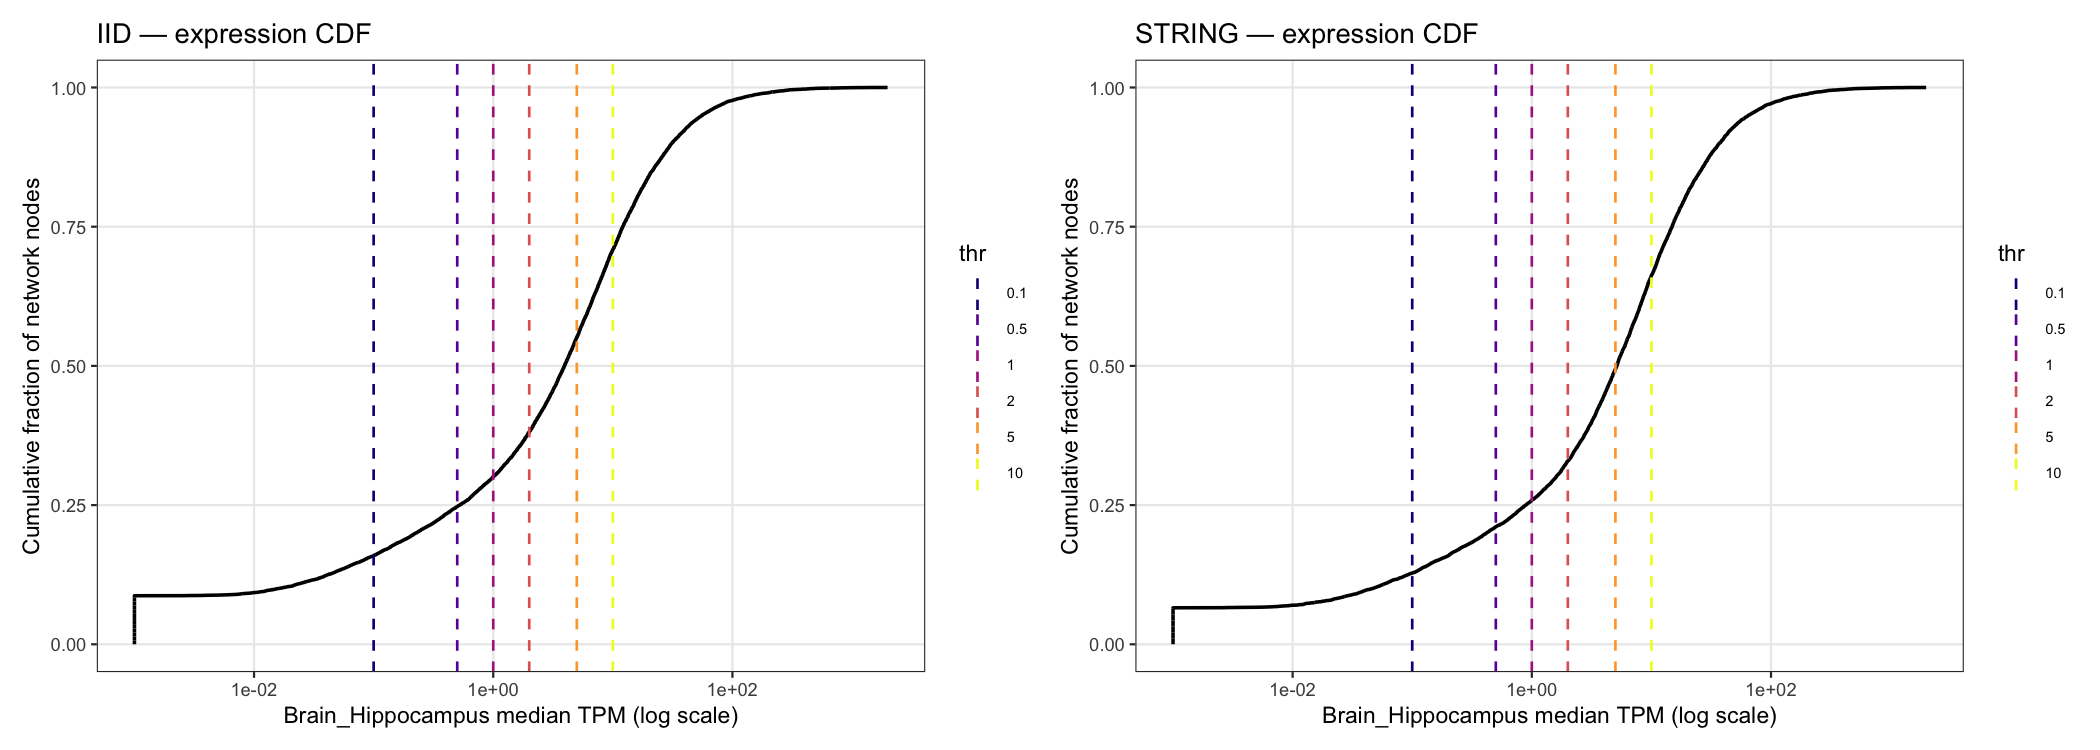

In [4]:
THRESHOLDS <- c(0.1, 0.5, 1.0, 2.0, 5.0, 10.0)

make_cdf_plot <- function(net_name) {
  nodes <- original_nodes[[net_name]]
  expr_in_net <- gct %>% filter(symbol %in% nodes) %>% pull(.data[[TISSUE]])
  expr_in_net <- expr_in_net[!is.na(expr_in_net)]
  # clip for visibility; log-scale x after
  expr_clipped <- pmax(expr_in_net, 1e-3)
  sorted_expr  <- sort(expr_clipped)
  cdf          <- seq_along(sorted_expr) / length(sorted_expr)
  df           <- tibble(x = sorted_expr, y = cdf)
  thr_df       <- tibble(thr = THRESHOLDS)

  ggplot(df, aes(x, y)) +
    geom_line(linewidth = 0.8) +
    geom_vline(data = thr_df, aes(xintercept = thr, color = factor(thr)), linetype = "dashed", linewidth = 0.6) +
    scale_color_viridis_d(option = "plasma", name = "thr") +
    scale_x_log10() +
    labs(x = paste(TISSUE, "median TPM (log scale)"), y = "Cumulative fraction of network nodes",
         title = paste0(toupper(net_name), " — expression CDF")) +
    theme_bw() +
    theme(legend.text = element_text(size = 7), panel.grid.minor = element_blank())
}

cdf_plots    <- map(names(NETWORKS), make_cdf_plot)
combined_cdf <- wrap_plots(cdf_plots, nrow = 1)
ggsave(file.path(OUT_ROOT, "expression_cdf.png"), combined_cdf, width = 14, height = 5, dpi = 150)
options(repr.plot.width = 14, repr.plot.height = 5)
combined_cdf

## 4 — Cross-source comparison: GTEx vs. PaxDB tissue clustering

How well do the two expression/abundance sources agree with each other on the mean–variance relationship across tissues? Shown for both raw values (log–log axes) and log2(x + 1)-transformed values (linear axes).

**Merged per request:** the raw-scale and log2-scale mean–variance plots are combined into a single 2×2 figure (GTEx/PaxDB × raw/log2) instead of two separate two-panel figures.

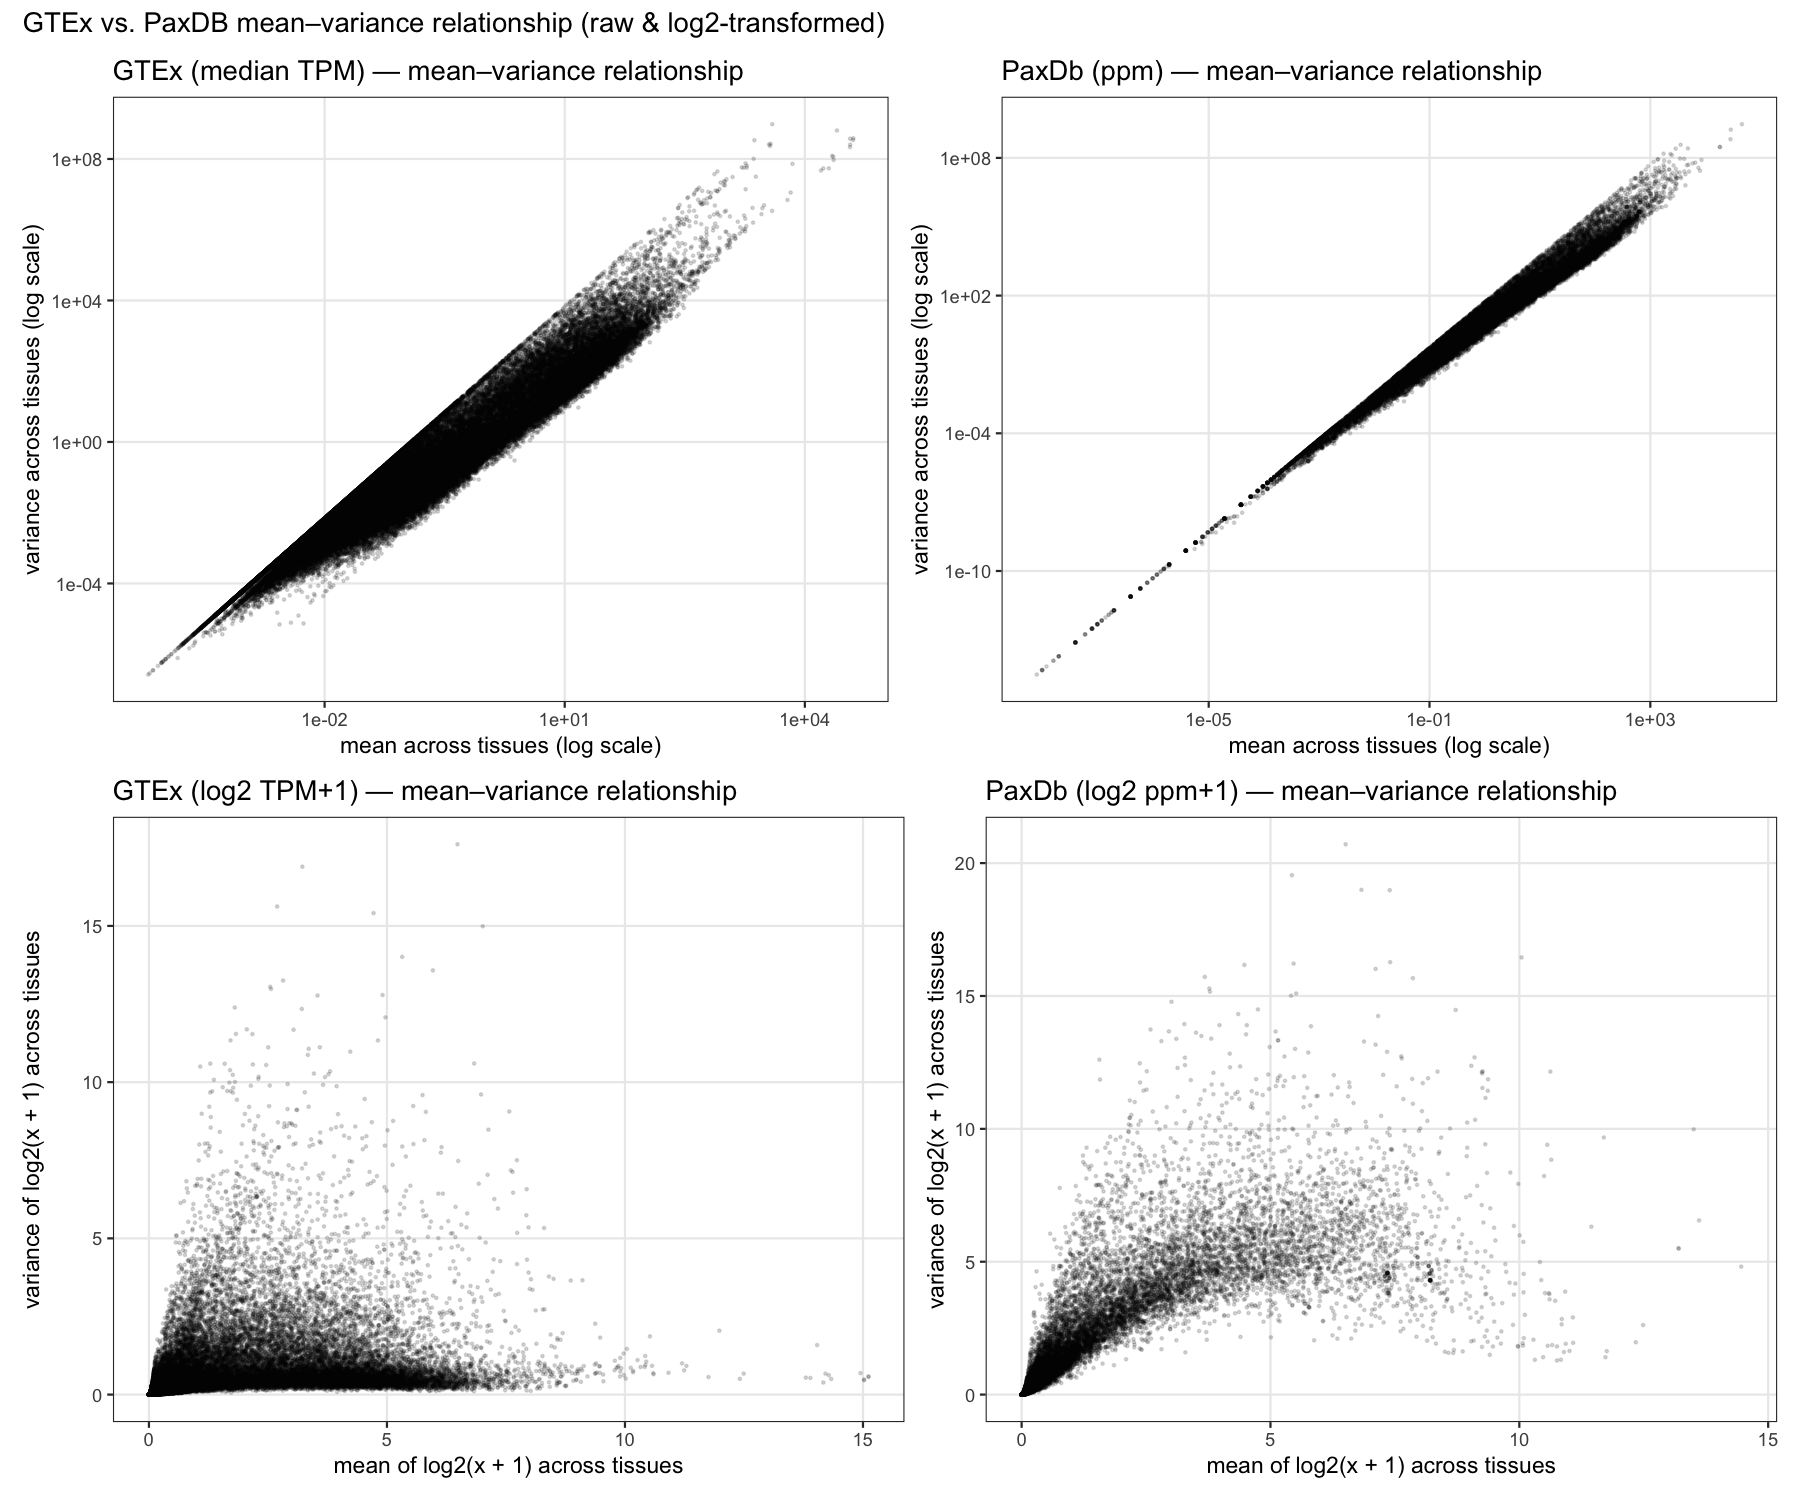

In [5]:
paxdb_mv <- read_tsv(file.path(REPO_ROOT, "data/paxdb_all_tissues.tsv"), show_col_types = FALSE)
# missing entries mean "not detected" (~0 abundance), not "unknown"
paxdb_mv <- paxdb_mv %>% mutate(across(-id, ~replace_na(.x, 0)))
paxdb_tissue_cols <- setdiff(colnames(paxdb_mv), "id")

gtex_mat  <- as.matrix(gtex_wide[tissue_cols])
paxdb_mat <- as.matrix(paxdb_mv[paxdb_tissue_cols])

gtex_mean  <- rowMeans(gtex_mat, na.rm = TRUE)
gtex_var   <- apply(gtex_mat, 1, var, na.rm = TRUE)
paxdb_mean <- rowMeans(paxdb_mat, na.rm = TRUE)
paxdb_var  <- apply(paxdb_mat, 1, var, na.rm = TRUE)

mean_var_raw <- bind_rows(
  tibble(source = "GTEx (median TPM)", mean = gtex_mean, var = gtex_var),
  tibble(source = "PaxDb (ppm)",       mean = paxdb_mean, var = paxdb_var)
) %>% filter(mean > 0, var > 0)

gtex_log  <- log2(gtex_mat + 1)
paxdb_log <- log2(paxdb_mat + 1)

mean_var_log <- bind_rows(
  tibble(source = "GTEx (log2 TPM+1)",  mean = rowMeans(gtex_log, na.rm = TRUE),  var = apply(gtex_log, 1, var, na.rm = TRUE)),
  tibble(source = "PaxDb (log2 ppm+1)", mean = rowMeans(paxdb_log, na.rm = TRUE), var = apply(paxdb_log, 1, var, na.rm = TRUE))
)

plot_mean_var <- function(df, source_name, log_scale, xlab, ylab) {
  p <- ggplot(filter(df, source == source_name), aes(mean, var)) +
    geom_point(size = 0.4, alpha = 0.15) +
    labs(x = xlab, y = ylab, title = paste0(source_name, " — mean–variance relationship")) +
    theme_bw() +
    theme(panel.grid.minor = element_blank())
  if (log_scale) p <- p + scale_x_log10() + scale_y_log10()
  p
}

p_gtex_raw  <- plot_mean_var(mean_var_raw, "GTEx (median TPM)", TRUE,
                              "mean across tissues (log scale)", "variance across tissues (log scale)")
p_paxdb_raw <- plot_mean_var(mean_var_raw, "PaxDb (ppm)", TRUE,
                              "mean across tissues (log scale)", "variance across tissues (log scale)")
p_gtex_log  <- plot_mean_var(mean_var_log, "GTEx (log2 TPM+1)", FALSE,
                              "mean of log2(x + 1) across tissues", "variance of log2(x + 1) across tissues")
p_paxdb_log <- plot_mean_var(mean_var_log, "PaxDb (log2 ppm+1)", FALSE,
                              "mean of log2(x + 1) across tissues", "variance of log2(x + 1) across tissues")

combined_mean_var <- (p_gtex_raw | p_paxdb_raw) / (p_gtex_log | p_paxdb_log) +
  plot_annotation(title = "GTEx vs. PaxDB mean–variance relationship (raw & log2-transformed)")
ggsave(file.path(OUT_ROOT, "mean_variance_gtex_paxdb_combined.png"), combined_mean_var, width = 12, height = 10, dpi = 200)
options(repr.plot.width = 12, repr.plot.height = 10)
combined_mean_var

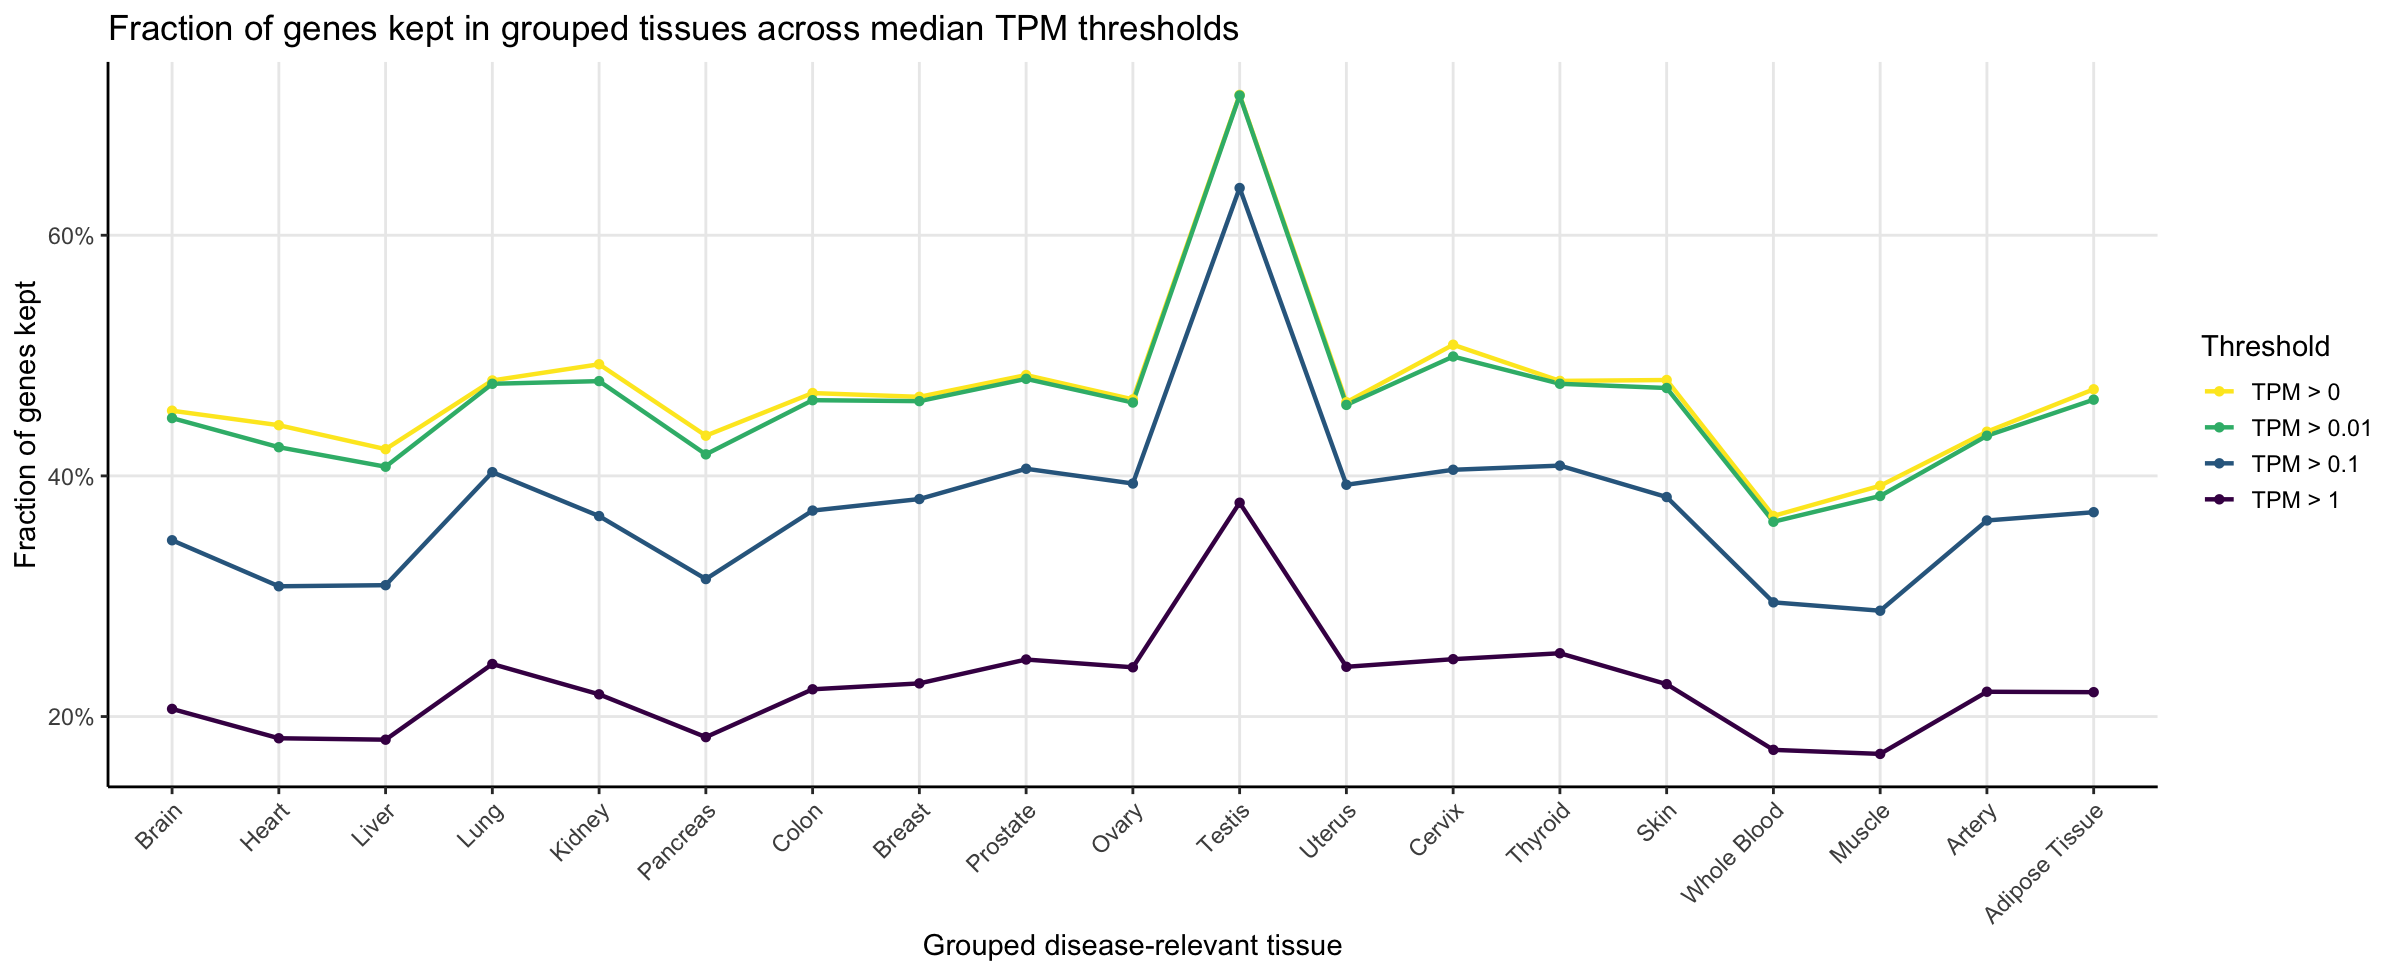

In [6]:
PARENT_TISSUE_OVERRIDES <- c(Whole_Blood = "Whole Blood")

# Multi-word organs need an explicit mapping; everything else collapses to its
# leading "_"-separated token (e.g. "Kidney_Cortex" -> "Kidney").
parent_tissue_name <- function(tissue_col) {
  if (tissue_col %in% names(PARENT_TISSUE_OVERRIDES)) return(PARENT_TISSUE_OVERRIDES[[tissue_col]])
  if (str_starts(tissue_col, "Adipose")) return("Adipose Tissue")
  str_split(tissue_col, "_")[[1]][1]
}

cutoffs     <- c(0, 0.01, 0.1, 1)
total_genes <- nrow(gct)

# Disease-focused tissues: broad organs with many well-characterized tissue-specific diseases.
disease_focused_tissues <- c(
  "Brain", "Heart", "Liver", "Lung", "Kidney", "Pancreas", "Colon", "Breast",
  "Prostate", "Ovary", "Testis", "Uterus", "Cervix", "Thyroid", "Skin",
  "Whole Blood", "Muscle", "Artery", "Adipose Tissue"
)

tissue_groups_full <- map_chr(tissue_cols, parent_tissue_name)
plot_order          <- disease_focused_tissues[disease_focused_tissues %in% tissue_groups_full]

# For each gene, collapse sub-tissues into one parent tissue by median TPM.
grouped_median_tpm <- sapply(plot_order, function(pt) {
  cols <- tissue_cols[tissue_groups_full == pt]
  if (length(cols) == 1) gtex_mat[, cols] else apply(gtex_mat[, cols, drop = FALSE], 1, median, na.rm = TRUE)
})
colnames(grouped_median_tpm) <- plot_order

fractions_by_cutoff <- map(cutoffs, function(cutoff) colSums(grouped_median_tpm > cutoff) / total_genes)
names(fractions_by_cutoff) <- paste0("TPM > ", cutoffs)

df_fraction <- map_dfr(names(fractions_by_cutoff), function(cn) {
  tibble(tissue = factor(plot_order, levels = plot_order), fraction = fractions_by_cutoff[[cn]], cutoff = cn)
})
df_fraction$cutoff <- factor(df_fraction$cutoff, levels = names(fractions_by_cutoff))

p_fraction <- ggplot(df_fraction, aes(tissue, fraction, color = cutoff, group = cutoff)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  scale_color_viridis_d(option = "viridis", direction = -1, name = "Threshold") +
  scale_y_continuous(labels = percent_format()) +
  labs(x = "Grouped disease-relevant tissue", y = "Fraction of genes kept",
       title = "Fraction of genes kept in grouped tissues across median TPM thresholds") +
  theme_bw(base_size = 14) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank(),
        panel.border = element_blank(),
        axis.line = element_line())

ggsave(file.path(OUT_ROOT, "gene_fraction_kept_by_threshold.png"), p_fraction, width = 16, height = 6.5, dpi = 150)
options(repr.plot.width = 16, repr.plot.height = 6.5)
p_fraction

## 10 — Detected-gene distributions for selected tissues

Fraction of genes detected for a few contrasting tissues plus a merged "Brain" trace (median across all `Brain_*` columns), shown as a per-bin density curve and as a cumulative distribution with candidate threshold lines at TPM = 0.01 / 0.1 / 1.

Merged brain tissues: 13 columns


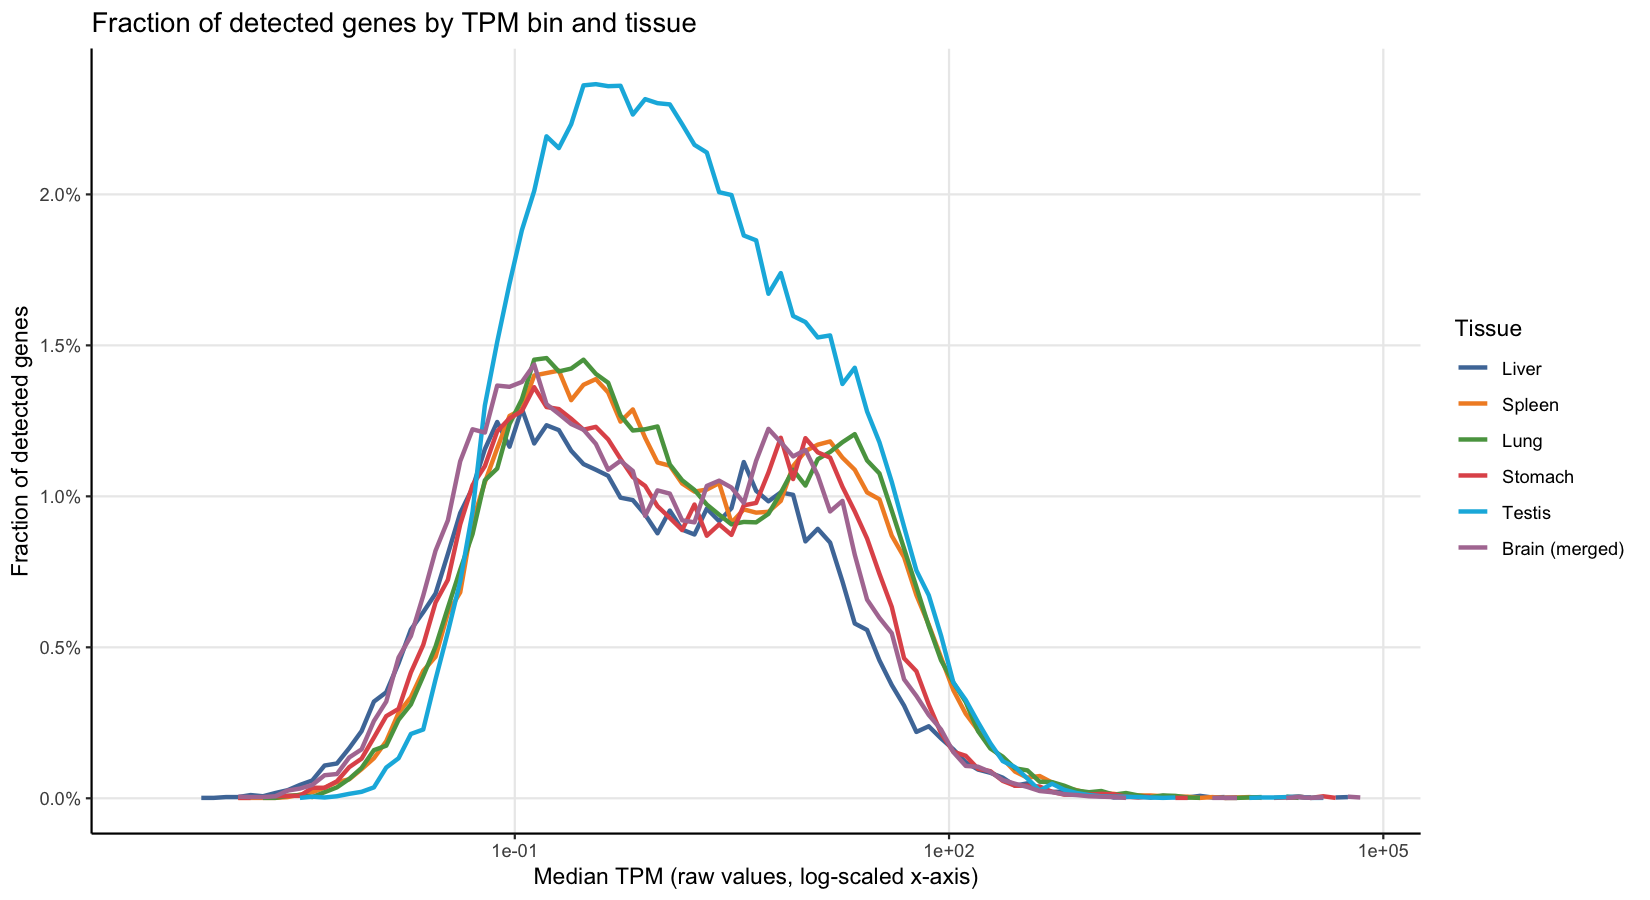

In [7]:
selected_tissues <- c("Liver", "Spleen", "Lung", "Stomach", "Testis")
brain_tissues     <- tissue_cols[str_starts(tissue_cols, "Brain_")]

expression_df <- gtex_wide %>% select(symbol, all_of(selected_tissues))
expression_df[["Brain (merged)"]] <- apply(as.matrix(gtex_wide[brain_tissues]), 1, median, na.rm = TRUE)

plot_order2 <- c("Liver", "Spleen", "Lung", "Stomach", "Testis", "Brain (merged)")
colors2 <- c(Liver = "#4e79a7", Spleen = "#f28e2b", Lung = "#59a14f",
             Stomach = "#e15759", Testis = "#0DB6E0", `Brain (merged)` = "#b07aa1")

# Shared log-spaced bins on raw TPM values (positive only for log-scaled x-axis).
all_values <- unlist(expression_df[plot_order2])
all_values <- all_values[!is.na(all_values) & all_values > 0]
vmin <- min(all_values); vmax <- max(all_values)
bin_edges   <- 10^seq(log10(vmin), log10(vmax), length.out = 100)
bin_centers <- sqrt(bin_edges[-length(bin_edges)] * bin_edges[-1])

hist_df <- map_dfr(plot_order2, function(tis) {
  values <- expression_df[[tis]]
  values <- values[!is.na(values) & values > 0]
  counts <- hist(values, breaks = bin_edges, plot = FALSE)$counts
  fractions <- counts / total_genes
  fractions[fractions <= 0] <- NA
  tibble(bin_center = bin_centers, fraction = fractions, tissue = tis)
})
hist_df$tissue <- factor(hist_df$tissue, levels = plot_order2)

p_detect_bin <- ggplot(hist_df, aes(bin_center, fraction, color = tissue)) +
  geom_line(linewidth = 1, na.rm = TRUE) +
  scale_color_manual(values = colors2, name = "Tissue") +
  scale_x_log10() +
  scale_y_continuous(labels = percent_format()) +
  labs(x = "Median TPM (raw values, log-scaled x-axis)", y = "Fraction of detected genes",
       title = "Fraction of detected genes by TPM bin and tissue") +
  theme_bw() +
  theme(panel.grid.minor = element_blank(), panel.border = element_blank(), axis.line = element_line())

ggsave(file.path(OUT_ROOT, "gene_detection_by_tpm_bin.png"), p_detect_bin, width = 11, height = 6, dpi = 150)
options(repr.plot.width = 11, repr.plot.height = 6)
p_detect_bin
cat("Merged brain tissues:", length(brain_tissues), "columns\n")

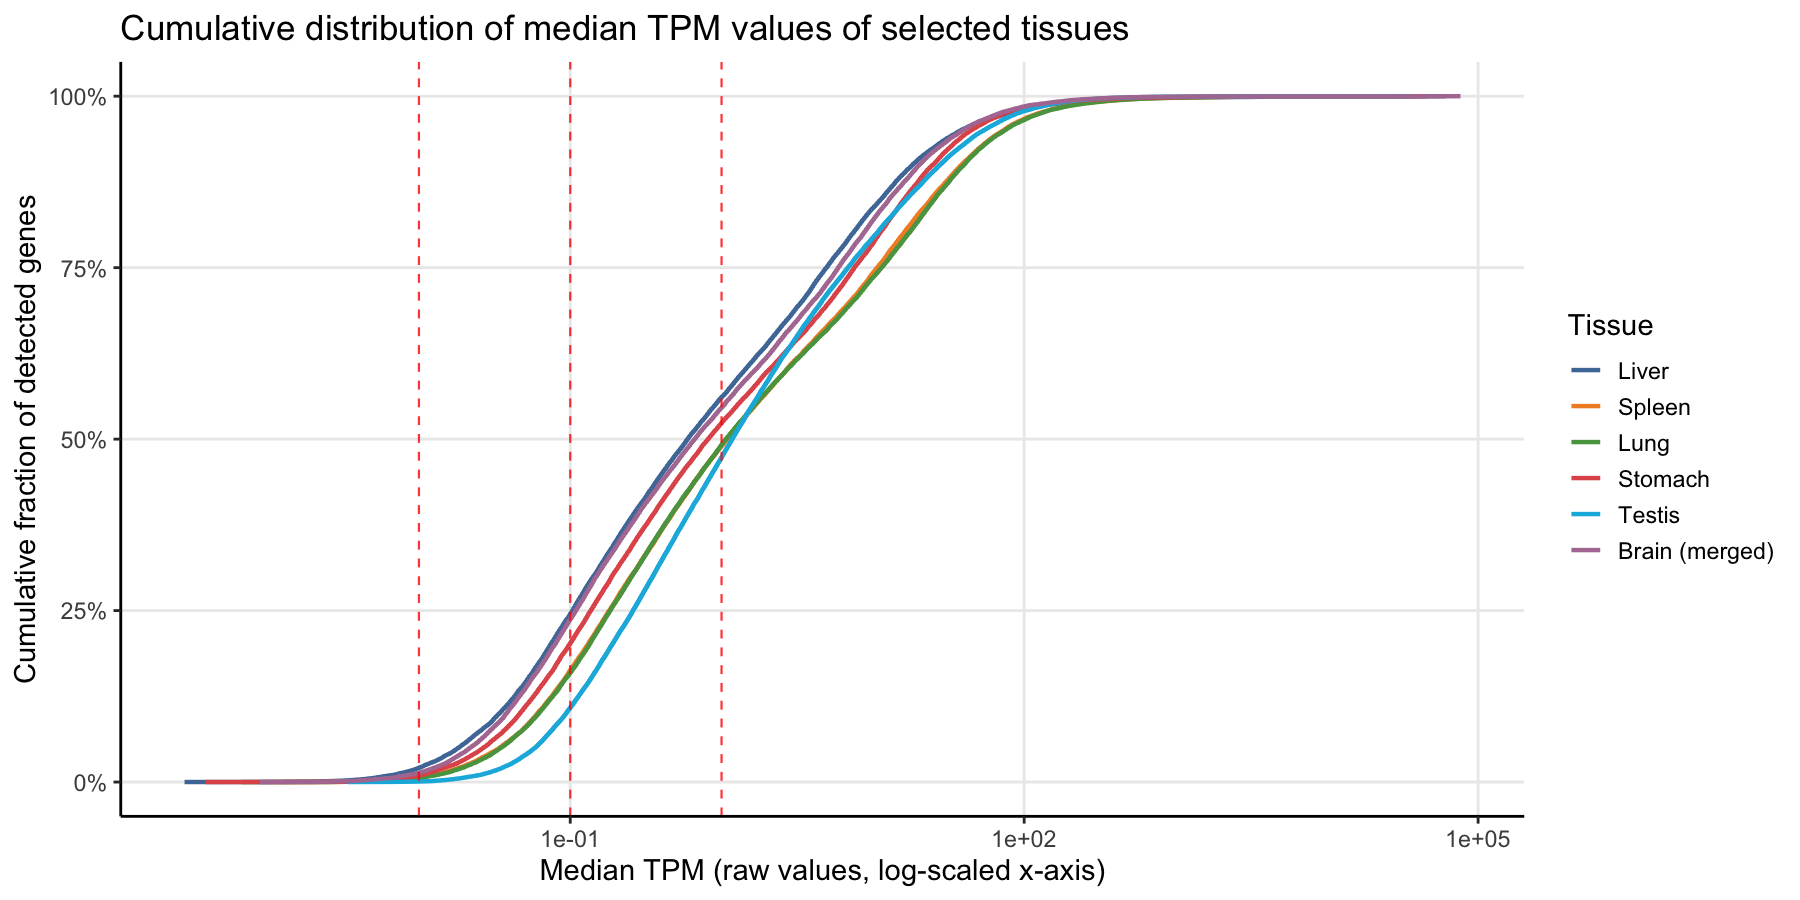

In [8]:
cdf_df <- map_dfr(plot_order2, function(tis) {
  values <- expression_df[[tis]]
  values <- values[!is.na(values) & values > 0]
  values_sorted <- sort(values)
  tibble(x = values_sorted, y = seq_along(values_sorted) / length(values_sorted), tissue = tis)
})
cdf_df$tissue <- factor(cdf_df$tissue, levels = plot_order2)

p_detect_cdf <- ggplot(cdf_df, aes(x, y, color = tissue)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(0.01, 0.1, 1), color = "red", linetype = "dashed", linewidth = 0.5, alpha = 0.8) +
  scale_color_manual(values = colors2, name = "Tissue") +
  scale_x_log10() +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  labs(x = "Median TPM (raw values, log-scaled x-axis)", y = "Cumulative fraction of detected genes",
       title = "Cumulative distribution of median TPM values of selected tissues") +
  theme_bw(base_size = 14) +
  theme(panel.grid.minor = element_blank(), panel.border = element_blank(), axis.line = element_line())

ggsave(file.path(OUT_ROOT, "gene_detection_cdf_selected_tissues.png"), p_detect_cdf, width = 12, height = 6, dpi = 150)
options(repr.plot.width = 12, repr.plot.height = 6)
p_detect_cdf

## 11 — Detected-protein distributions for selected tissues (PaxDB)

Same analysis as Section 10, but using PaxDB protein abundance (ppm) instead of GTEx TPM. The merged "Brain (merged)" trace is the median across `ASTROCYTE`, `BRAIN`, `CEREBRAL_CORTEX`, `FRONTAL_CORTEX` — the PaxDB tissues mapped to the "brain" organ group in `data/tissue_uberon_groups.tsv`.

Merged brain tissues: 4 columns


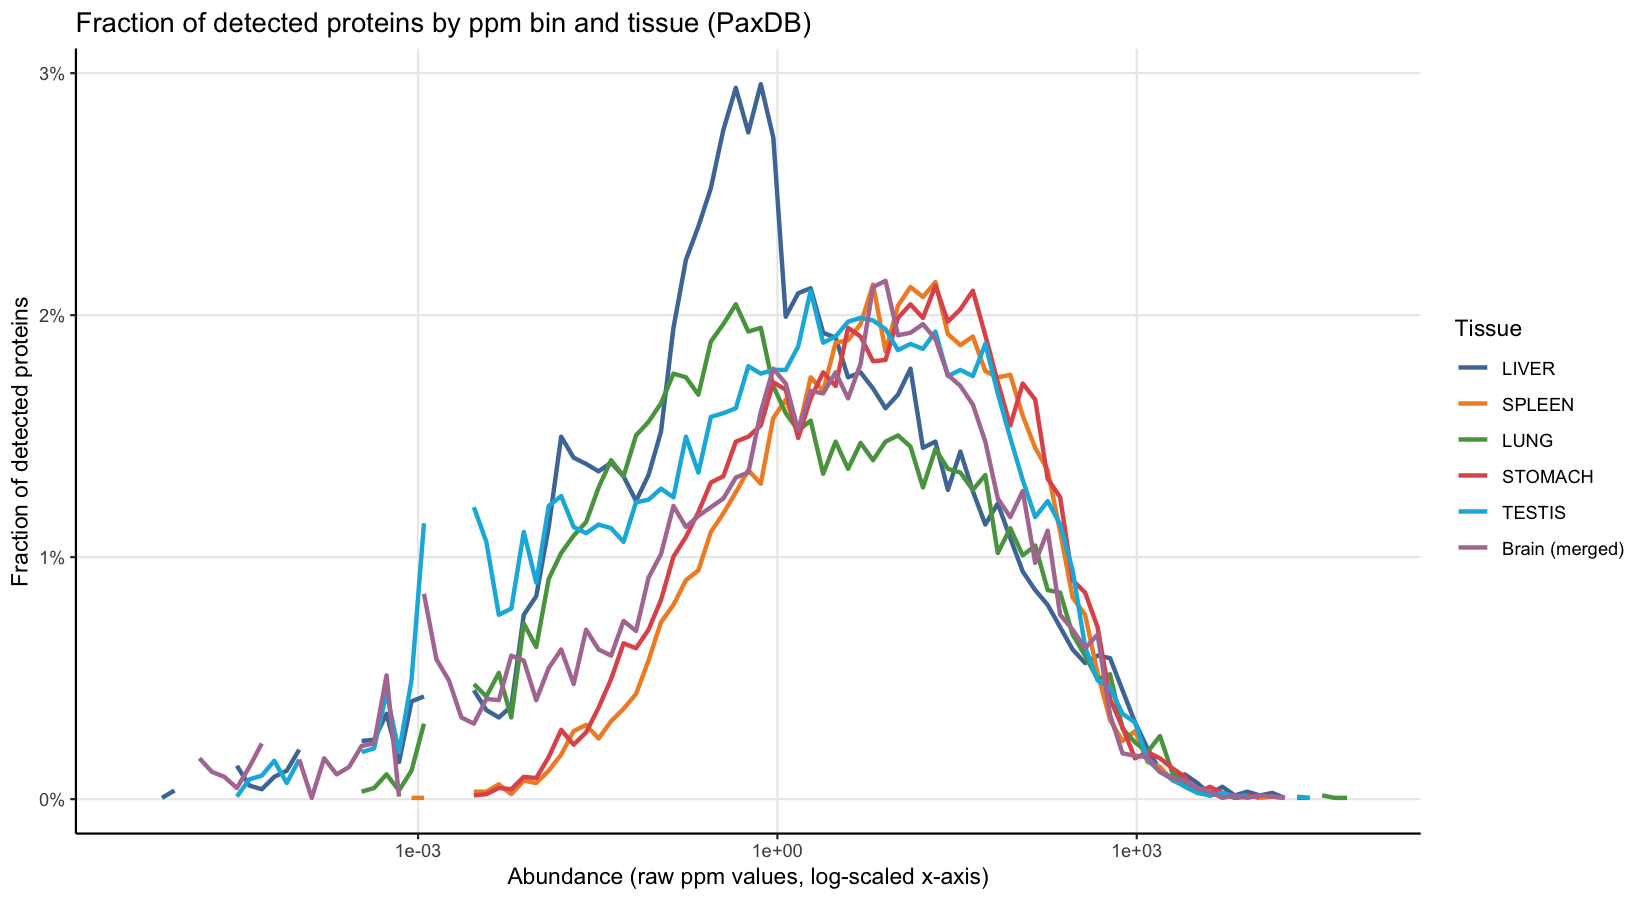

In [9]:
paxdb_selected_tissues <- c("LIVER", "SPLEEN", "LUNG", "STOMACH", "TESTIS")
paxdb_brain_tissues     <- c("ASTROCYTE", "BRAIN", "CEREBRAL_CORTEX", "FRONTAL_CORTEX")
total_proteins <- nrow(paxdb_mv)

paxdb_expression_df <- paxdb_mv %>% select(id, all_of(paxdb_selected_tissues))
paxdb_expression_df[["Brain (merged)"]] <- apply(as.matrix(paxdb_mv[paxdb_brain_tissues]), 1, median, na.rm = TRUE)

paxdb_plot_order <- c("LIVER", "SPLEEN", "LUNG", "STOMACH", "TESTIS", "Brain (merged)")
paxdb_colors <- c(LIVER = "#4e79a7", SPLEEN = "#f28e2b", LUNG = "#59a14f",
                   STOMACH = "#e15759", TESTIS = "#0DB6E0", `Brain (merged)` = "#b07aa1")

# Shared log-spaced bins on raw ppm values (positive only for log-scaled x-axis).
paxdb_all_values <- unlist(paxdb_expression_df[paxdb_plot_order])
paxdb_all_values <- paxdb_all_values[!is.na(paxdb_all_values) & paxdb_all_values > 0]
vmin <- min(paxdb_all_values); vmax <- max(paxdb_all_values)
paxdb_bin_edges   <- 10^seq(log10(vmin), log10(vmax), length.out = 100)
paxdb_bin_centers <- sqrt(paxdb_bin_edges[-length(paxdb_bin_edges)] * paxdb_bin_edges[-1])

paxdb_hist_df <- map_dfr(paxdb_plot_order, function(tis) {
  values <- paxdb_expression_df[[tis]]
  values <- values[!is.na(values) & values > 0]
  counts <- hist(values, breaks = paxdb_bin_edges, plot = FALSE)$counts
  fractions <- counts / total_proteins
  fractions[fractions <= 0] <- NA
  tibble(bin_center = paxdb_bin_centers, fraction = fractions, tissue = tis)
})
paxdb_hist_df$tissue <- factor(paxdb_hist_df$tissue, levels = paxdb_plot_order)

p_paxdb_detect_bin <- ggplot(paxdb_hist_df, aes(bin_center, fraction, color = tissue)) +
  geom_line(linewidth = 1, na.rm = TRUE) +
  scale_color_manual(values = paxdb_colors, name = "Tissue") +
  scale_x_log10() +
  scale_y_continuous(labels = percent_format()) +
  labs(x = "Abundance (raw ppm values, log-scaled x-axis)", y = "Fraction of detected proteins",
       title = "Fraction of detected proteins by ppm bin and tissue (PaxDB)") +
  theme_bw() +
  theme(panel.grid.minor = element_blank(), panel.border = element_blank(), axis.line = element_line())

ggsave(file.path(OUT_ROOT, "paxdb_protein_detection_by_ppm_bin.png"), p_paxdb_detect_bin, width = 11, height = 6, dpi = 150)
options(repr.plot.width = 11, repr.plot.height = 6)
p_paxdb_detect_bin
cat("Merged brain tissues:", length(paxdb_brain_tissues), "columns\n")

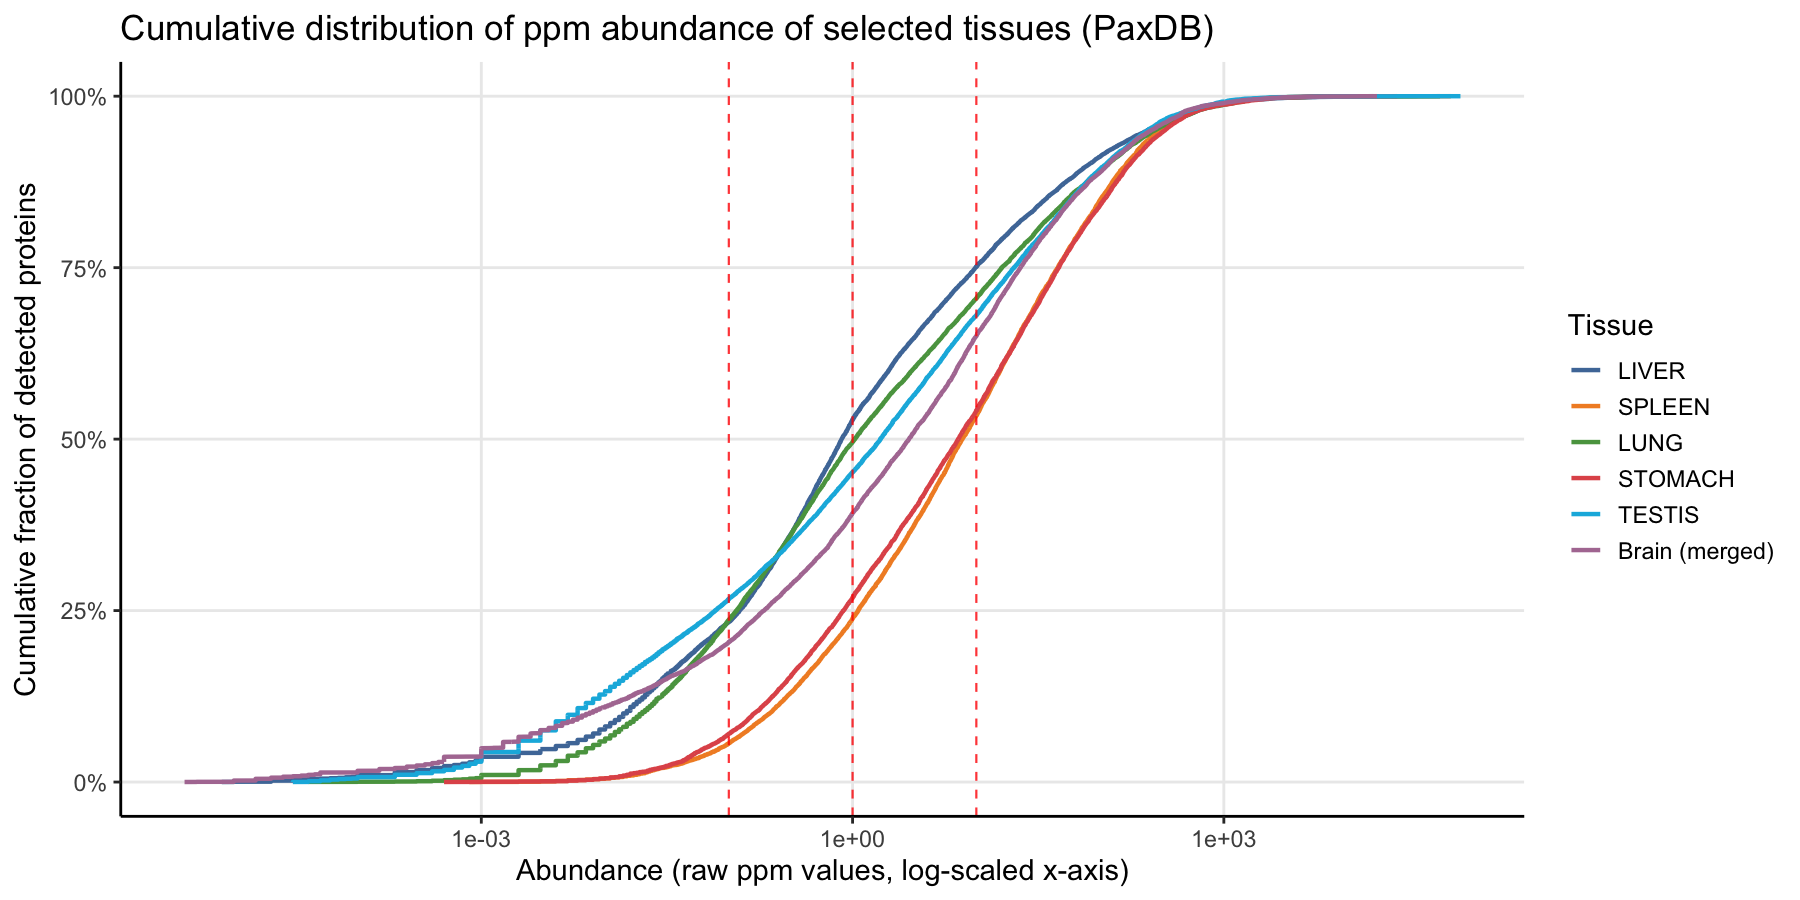

In [10]:
paxdb_cdf_df <- map_dfr(paxdb_plot_order, function(tis) {
  values <- paxdb_expression_df[[tis]]
  values <- values[!is.na(values) & values > 0]
  values_sorted <- sort(values)
  tibble(x = values_sorted, y = seq_along(values_sorted) / length(values_sorted), tissue = tis)
})
paxdb_cdf_df$tissue <- factor(paxdb_cdf_df$tissue, levels = paxdb_plot_order)

p_paxdb_detect_cdf <- ggplot(paxdb_cdf_df, aes(x, y, color = tissue)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(0.1, 1, 10), color = "red", linetype = "dashed", linewidth = 0.5, alpha = 0.8) +
  scale_color_manual(values = paxdb_colors, name = "Tissue") +
  scale_x_log10() +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  labs(x = "Abundance (raw ppm values, log-scaled x-axis)", y = "Cumulative fraction of detected proteins",
       title = "Cumulative distribution of ppm abundance of selected tissues (PaxDB)") +
  theme_bw(base_size = 14) +
  theme(panel.grid.minor = element_blank(), panel.border = element_blank(), axis.line = element_line())

ggsave(file.path(OUT_ROOT, "paxdb_protein_detection_cdf_selected_tissues.png"), p_paxdb_detect_cdf, width = 12, height = 6, dpi = 150)
options(repr.plot.width = 12, repr.plot.height = 6)
p_paxdb_detect_cdf